In [1]:
!pip -q install japanize-matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import japanize_matplotlib
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
# データの読み込み
file_path = "./parquet_data/1571_ja.parquet"

try:
    df = pd.read_parquet(file_path)
    print(f"データ読み込み成功：{df.shape[0]}行, {df.shape[1]}列")
    display(df.head())
except Exception:
    print(f"ファイルが読み込めませんでした。")

データ読み込み成功：29846行, 4028列


,PanelID,w1回答フラグ,w2回答フラグ,w3回答フラグ,w4回答フラグ,w5回答フラグ,w6回答フラグ,w7回答フラグ,w1学年,w2学年,...,w7p_性別（第4子）,w7p_性別（第5子）,w7p_性別（第6子）,w7p_年齢（第1子）,w7p_年齢（第2子）,w7p_年齢（第3子）,w7p_年齢（第4子）,w7p_年齢（第5子）,w7p_年齢（第6子）,w7p_調査対象のお子様の出生順位
0,1600001,6,1,1,1,1,1,1,8888.0,1.0,...,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0
1,1600002,6,1,1,1,1,1,4,8888.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1600003,6,1,1,1,4,1,1,8888.0,1.0,...,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0
3,1600004,6,1,1,1,1,1,1,8888.0,1.0,...,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0
4,1600005,6,1,1,1,1,1,1,8888.0,1.0,...,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0,7777.0


In [4]:
# 分析対象変数の定義と抽出
# カラム名の検索キーワード
col_w1_fail = [col for col in df.columns if "w1c_13_23" in col or "大きな失敗" in col]
col_w1_recover = [col for col in df.columns if "w1c_23_12" in col or "失敗しても自信" in col]
col_w7_challenge = [col for col in df.columns if ("w7" in col or "W7" in col) and "挑戦" in col]
col_w1_parent_talk = [col for col in df.columns if "w1c_13_11" in col or "仕事の楽しさ" in col]
col_w1_self_decide = [col for col in df.columns if "w1c_22_15" in col or "自分で決めて行動" in col]

# 複数ヒットした場合に「最初の1列」を安全に取得する補助関数
def get_single_col(col_list, var_name):
    if len(col_list) == 0:
        raise ValueError(
            f"エラー：'{var_name}' に該当するカラムが見つかりませんでした。"
        )
    if len(col_list) > 1:
        print(
            f"'{var_name}' に {len(col_list)} 件ヒットしたため、先頭の列 '{col_list[0]}' を採用します。"
        )
    return col_list[0]


# 各変数から1列ずつ特定
c_fail = get_single_col(col_w1_fail, "W1_挫折経験")
c_recover = get_single_col(col_w1_recover, "W1_回復力")
c_challenge = get_single_col(col_w7_challenge, "W7_挑戦心")
c_parent = get_single_col(col_w1_parent_talk, "W1_親の仕事対話")
c_self = get_single_col(col_w1_self_decide, "W1_自己決定")

# 確定した5列のリスト
target_cols = [c_fail, c_recover, c_challenge, c_parent, c_self]

print("\n採用された5つのカラム")
for name, col in zip(
    [
        "W1_挫折経験",
        "W1_回復力",
        "W7_挑戦心",
        "W1_親の仕事対話",
        "W1_自己決定",
    ],
    target_cols,
):
    print(f"・{name}：{col}")

'W1_挫折経験' に 3 件ヒットしたため、先頭の列 'w1c_経験：立ち直れないような大きな失敗をする' を採用します。
'W1_回復力' に 6 件ヒットしたため、先頭の列 'w1c_性格・特性：失敗しても自信を取り戻せる' を採用します。
'W7_挑戦心' に 4 件ヒットしたため、先頭の列 'w7c_経験：無理だと思うようなことに挑戦する' を採用します。
'W1_親の仕事対話' に 5 件ヒットしたため、先頭の列 'w1c_経験：親から仕事の楽しさや大変さを聞く' を採用します。
'W1_自己決定' に 14 件ヒットしたため、先頭の列 'w1c_得意・苦手：自分で決めて行動すること' を採用します。

採用された5つのカラム
・W1_挫折経験：w1c_経験：立ち直れないような大きな失敗をする
・W1_回復力：w1c_性格・特性：失敗しても自信を取り戻せる
・W7_挑戦心：w7c_経験：無理だと思うようなことに挑戦する
・W1_親の仕事対話：w1c_経験：親から仕事の楽しさや大変さを聞く
・W1_自己決定：w1c_得意・苦手：自分で決めて行動すること


In [11]:
# データの整形
# 無効値をNaNに置換する関数
def clean_code(series):
    return series.apply(lambda x: np.nan if x in [7777, 8888, 9999, 99] else x)

# 5列だけをコピー
df_anal = df[target_cols].copy()

# カラム名を新しい名称に変更
df_anal.columns = [
    "W1_挫折経験",
    "W1_回復力",
    "W7_挑戦心",
    "W1_親の仕事対話",
    "W1_自己決定",
]

# 各カラムのデータクレンジング
for col in df_anal.columns:
    df_anal[col] = clean_code(df_anal[col])

# 有効回答者のみに絞り込み
df_clean = df_anal.dropna(
    subset=["W1_挫折経験", "W1_回復力", "W7_挑戦心"]
).copy()

# グループ分け（1, 2＝肯定回答）
df_clean["挫折経験あり"] = df_clean["W1_挫折経験"].isin([1, 2])
df_clean["挫折克服あり"] = df_clean["W1_回復力"].isin([1, 2])
df_clean["W7高挑戦心"] = df_clean["W7_挑戦心"].isin([1, 2])

# セグメント分類
conditions = [(df_clean["挫折経験あり"] == True) & (df_clean["挫折克服あり"] == True),
              (df_clean["挫折経験あり"] == True) & (df_clean["挫折克服あり"] == False),
              (df_clean["挫折経験あり"] == False)]

choices = ["挫折を克服した", "挫折しただけ", "挫折すらしてない"]
df_clean["グループ"] = np.select(conditions, choices, default="その他")

print("クレンジングとグループ分けが正常に完了しました！")

クレンジングとグループ分けが正常に完了しました！


In [6]:
# 集計結果の出力
print("挫折後の「克服経験」が7年後の挑戦心に与える影響")

summary = (
    df_clean.groupby("グループ")["W7高挑戦心"]
    .agg(対象人数="size", 平均値="mean")
    .reset_index()
)

# 割合（%）に変換
summary["7年後に高い挑戦心を持つ割合(%)"] = (
    summary["平均値"] * 100
).round(1)

# 表示用データフレームの整理
output_df = summary[["グループ", "対象人数", "7年後に高い挑戦心を持つ割合(%)"]]
display(output_df)

挫折後の「克服経験」が7年後の挑戦心に与える影響


,グループ,対象人数,7年後に高い挑戦心を持つ割合(%)
0,挫折しただけ,122,16.4
1,挫折すらしてない,2208,16.3
2,挫折を克服した,205,25.4


C:\Users\rei19\AppData\Local\Temp\ipykernel_7360\2647817659.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


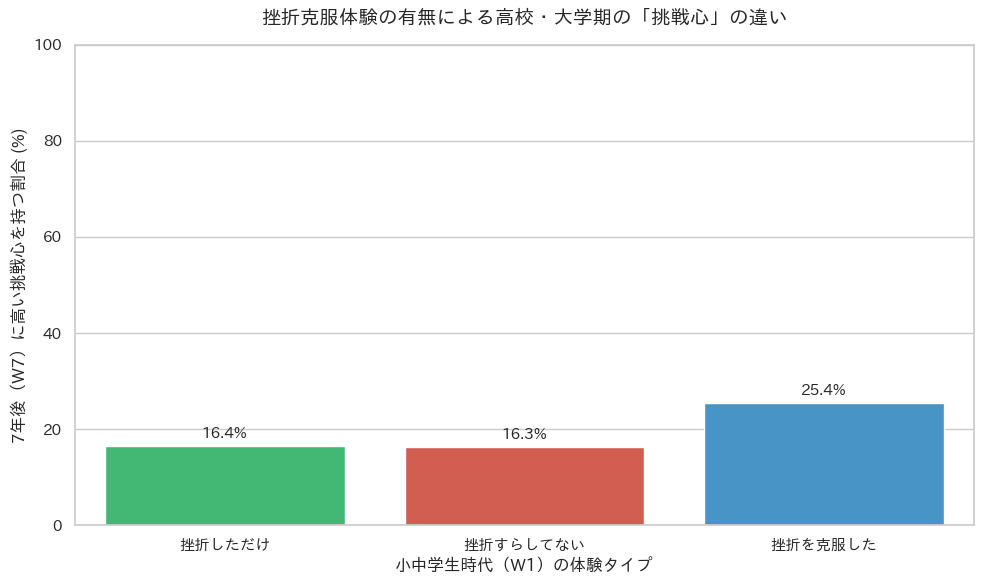

In [7]:
# グラフ作成
plt.figure(figsize=(10, 6))

sns.set_theme(style="whitegrid", font="IPAexGothic")

plot_data = summary[summary["グループ"] != "その他"]

ax = sns.barplot(
    data=plot_data,
    x="グループ",
    y="7年後に高い挑戦心を持つ割合(%)",
    palette=["#2ecc71", "#e74c3c", "#3498db"],
)

plt.title(
    "挫折克服体験の有無による高校・大学期の「挑戦心」の違い",
    fontsize=14,
    pad=15,
)
plt.xlabel("小中学生時代（W1）の体験タイプ", fontsize=12)
plt.ylabel("7年後（W7）に高い挑戦心を持つ割合 (%)", fontsize=12)
plt.ylim(0, 100)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 9),
            textcoords="offset points",
            fontsize=11,
            weight="bold",
        )

plt.tight_layout()
plt.savefig("resilience_impact_graph.png", dpi=300)
plt.show()

In [10]:
# 分析用のデータセット作成（欠損値を除外）
# 目的変数：W7高挑戦心 (1 / 0)
# 説明変数：グループ（挫折なし群を基準カテゴリに設定）、親の仕事対話、自己決定力
df_model = df_clean.dropna(
    subset=["W7高挑戦心", "グループ", "W1_親の仕事対話", "W1_自己決定"]
).copy()

# 目的変数を数値（0, 1）に変換
df_model["y"] = df_model["W7高挑戦心"].astype(int)

# 「親の仕事対話」「自己決定」も肯定回答（1, 2）を1、それ以外を0とするダミー変数化
df_model["親の仕事対話あり"] = df_model["W1_親の仕事対話"].isin([1, 2]).astype(int)
df_model["自己決定傾向あり"] = df_model["W1_自己決定"].isin([1, 2]).astype(int)

# 2. ロジスティック回帰モデルの構築と適用
# 基準（Reference）を「挫折すらしてない」に固定して比較
model_formula = "y ~ C(グループ, Treatment(reference='挫折すらしてない')) + 親の仕事対話あり + 自己決定傾向あり"
logit_model = smf.logit(formula=model_formula, data=df_model).fit()

# 3. 分析結果のサマリー表示
print("【ロジスティック回帰分析 結果サマリー】")
print(logit_model.summary())

params = logit_model.params
conf = logit_model.conf_int()
conf["Odds Ratio"] = params
conf.columns = ["2.5%", "97.5%", "Odds Ratio"]

# 指数関数化してオッズ比を復元
odds_ratios = np.exp(conf)
odds_ratios["p-value"] = logit_model.pvalues

print("\n【主要変数のオッズ比 (Odds Ratio) と 統計的有意性 (p値)】")
print(odds_ratios.round(3))

Optimization terminated successfully.
         Current function value: 0.444717
         Iterations 6
【ロジスティック回帰分析 結果サマリー】
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 2514
Model:                          Logit   Df Residuals:                     2509
Method:                           MLE   Df Model:                            4
Date:                Thu, 13 Aug 2026   Pseudo R-squ.:                 0.01990
Time:                        14:18:37   Log-Likelihood:                -1118.0
converged:                       True   LL-Null:                       -1140.7
Covariance Type:            nonrobust   LLR p-value:                 3.268e-09
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Inter